# Burst Experiment — Simplified 3-Phase Pipeline

Three independent phases:
1. **Pretrain** — train on background tasks until convergence (run once)
2. **Finetune** — burst phase with configurable concentration (sweep here)
3. **Forget** — reversion phase, measure how quickly burst knowledge is lost

Each phase saves checkpoints so you can re-run downstream phases without retraining upstream.

In [24]:
import sys, os
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")
from simple import make_data, pretrain, finetune, forget, report, interp
import matplotlib.pyplot as plt
%matplotlib inline

OUT = "data/simple_burst"

## 1. Generate Data

One call, reuse across all phases. Adjust `depth`, `burst_pos`, `n_a` to change task complexity.

In [16]:
data = make_data(depth=3, burst_pos=3, n_a=4)
print(f"Vocab: {data['vocab_size']}, Context: {data['context_size']}, Prompt: {data['prompt_len']}")
print(f"Other tasks: {data['task_info']['n_other_tasks']}, Burst tasks: {data['task_info']['n_burst_tasks']}")

Vocab: 37, Context: 37, Prompt: 12
Other tasks: 64, Burst tasks: 16


## 2. Pretrain (run once)

Trains on background data until loss plateaus. Saves checkpoint to reuse.

Pretrain: 0it [00:00, ?it/s]


Converged at step 700 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=0.9998, final loss_other=0.5865


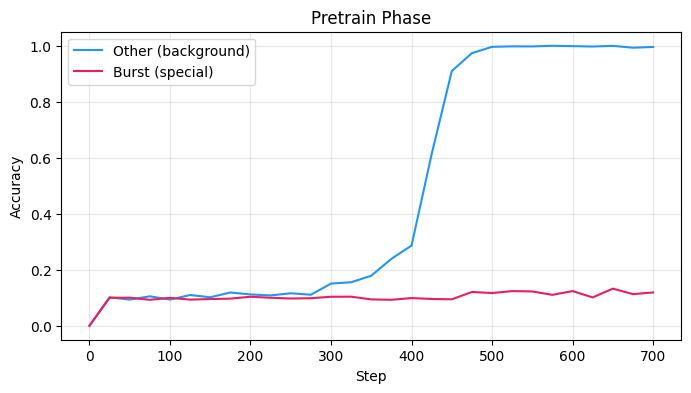

Checkpoint: data/simple_burst/pretrain/pretrain_ckpt.pt


In [17]:
pt = pretrain(data, f"{OUT}/pretrain")
report.plot_pretrain(pt)
plt.show()
print(f"Checkpoint: {pt['ckpt_path']}")

## 3. Finetune — sweep over burst fractions

Each run loads the same pretrained checkpoint. Edit `FRACS` to test different concentrations.

  burst_100: peak_burst=1.000
  burst_90: peak_burst=1.000
  burst_50: peak_burst=1.000
  burst_25: peak_burst=1.000
  burst_10: peak_burst=0.997


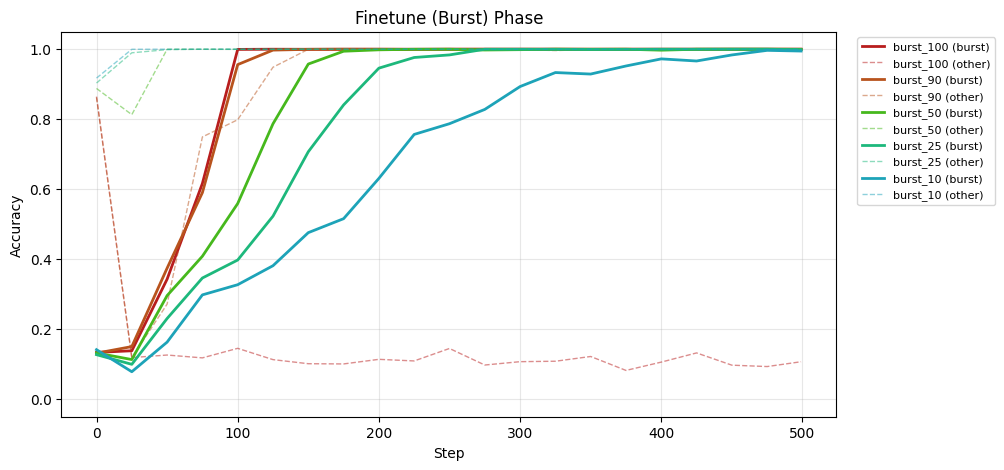

In [18]:
import torch.multiprocessing as mp
from simple.finetune import _finetune_worker

FRACS = [1.0, 0.9, 0.5, 0.25, 0.10]  # sweep these

jobs = [dict(data=data, pretrain_ckpt=pt["ckpt_path"], out_dir=f"{OUT}/finetune",
             burst_frac=frac, steps=500, quiet=True)
        for frac in FRACS]

ctx = mp.get_context("spawn")
with ctx.Pool(len(FRACS)) as pool:
    ft_results = pool.map(_finetune_worker, jobs)

for r in ft_results:
    print(f"  {r['tag']}: peak_burst={r['peak_burst']:.3f}")

report.plot_finetune(ft_results)
plt.show()

## 4. Forget — measure reversion for each finetuned model

  burst_100: peak=1.000 -> end=0.119 (drop 88.1%)
  burst_90: peak=1.000 -> end=0.181 (drop 81.9%)
  burst_50: peak=1.000 -> end=0.396 (drop 60.4%)
  burst_25: peak=0.998 -> end=0.343 (drop 65.7%)
  burst_10: peak=0.995 -> end=0.497 (drop 50.0%)


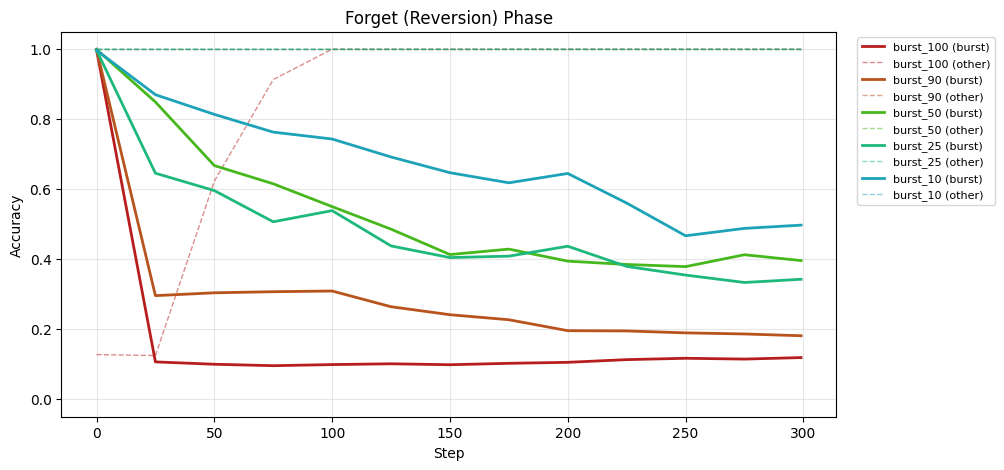

In [19]:
from simple.forget import _forget_worker

jobs = [dict(data=data, finetune_ckpt=ft["ckpt_path"], out_dir=f"{OUT}/forget",
             pretrain_ckpt=pt["ckpt_path"], steps=300, quiet=True)
        for ft in ft_results]

with ctx.Pool(len(ft_results)) as pool:
    fg_results = pool.map(_forget_worker, jobs)

for r in fg_results:
    print(f"  {r['tag']}: peak={r['peak_burst']:.3f} -> end={r['end_burst_acc']:.3f} "
          f"(drop {r['dropoff_pct']:.1f}%)")

report.plot_forget(fg_results)
plt.show()

## 5. Summary Table

In [20]:
# Summary table
rows = report.summary_table(ft_results, fg_results)

Tag             Burst%   Peak    End  Drop%      AUC 95%-life 80%-life
----------------------------------------------------------------------
burst_100         100%  1.000  0.119   88.1       43   25.000   25.000
burst_90           90%  1.000  0.181   81.9       82   25.000   25.000
burst_50           50%  1.000  0.396   60.4      157   25.000   50.000
burst_25           25%  1.000  0.343   65.7      143   25.000   25.000
burst_10           10%  0.997  0.497   50.0      201   25.000   75.000


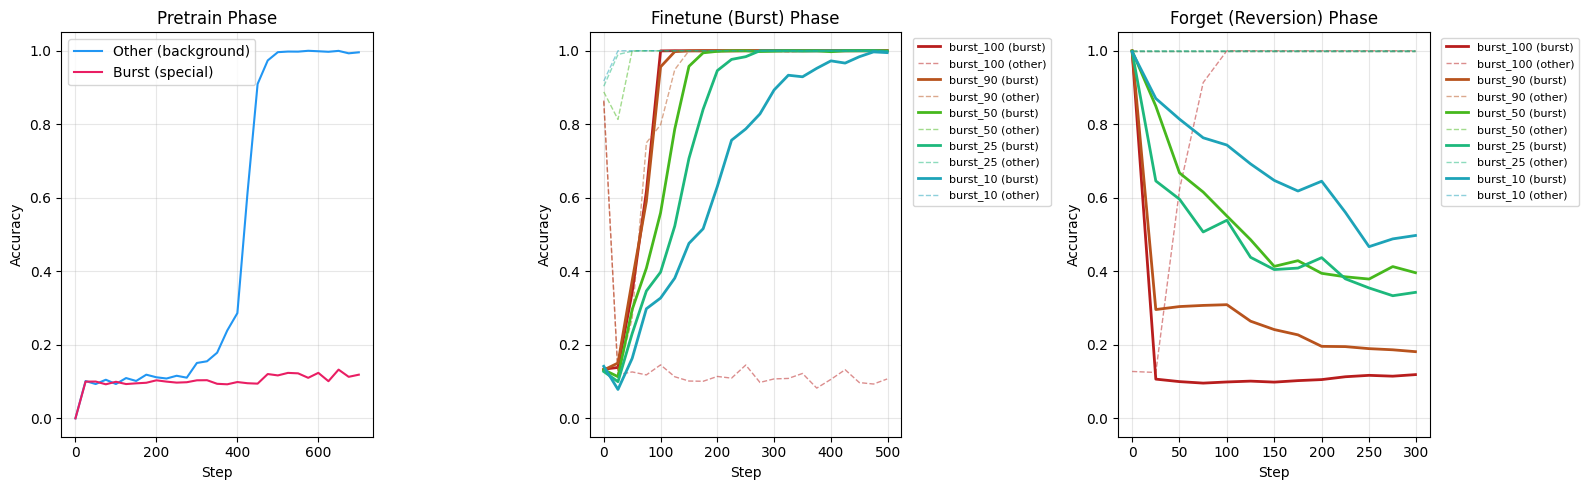

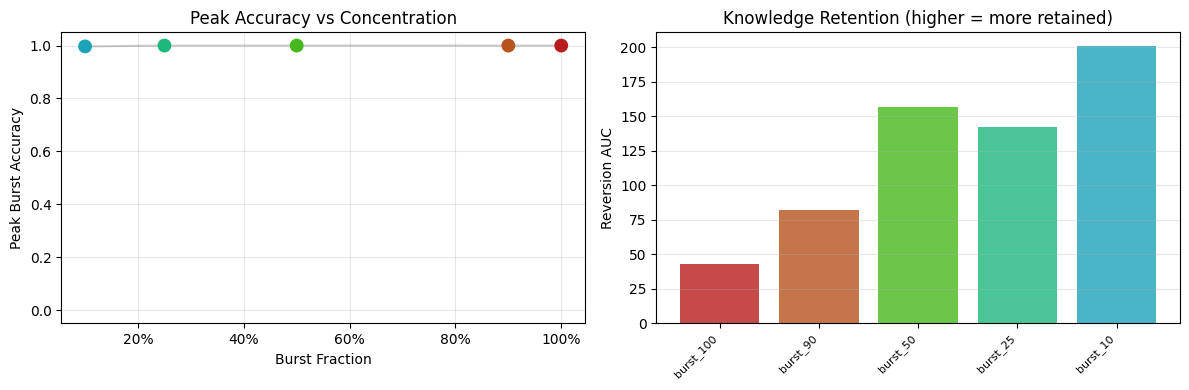

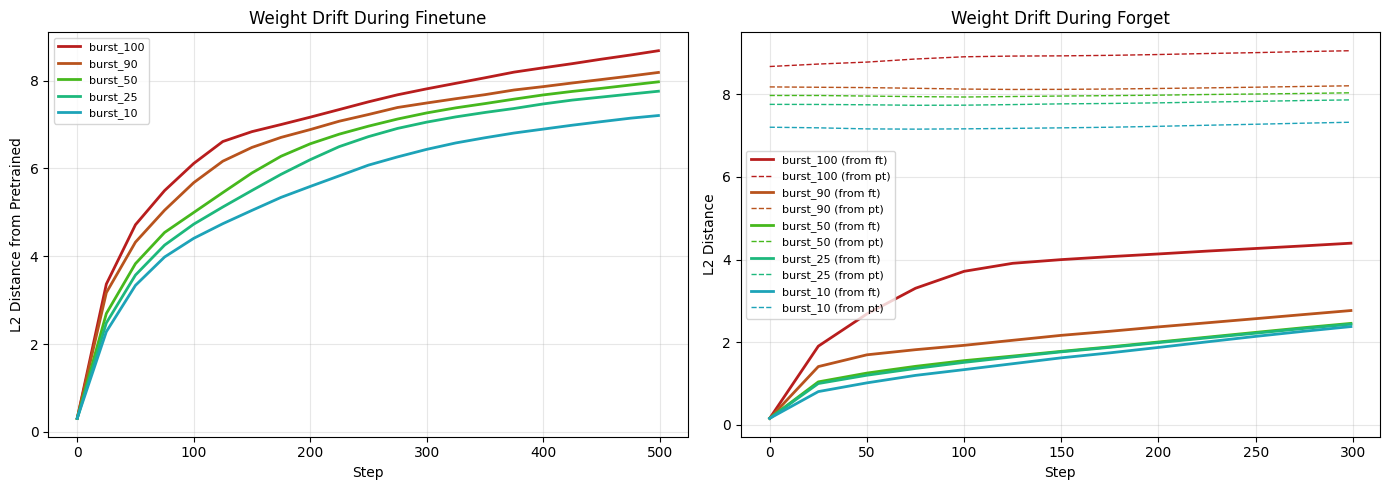

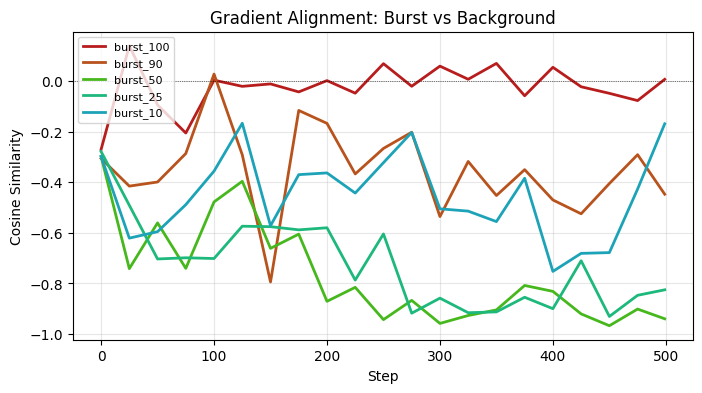

In [21]:
# Full trajectory + comparison charts
fig = report.plot_full_trajectory(pt, ft_results, fg_results)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
report.plot_peak_vs_frac(ft_results, axes[0])
report.plot_retention_vs_frac(fg_results, axes[1])
fig.tight_layout()
plt.show()

# Weight drift & gradient alignment during training
fig = report.plot_weight_drift(ft_results, fg_results)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
report.plot_grad_cosine(ft_results, ax)
plt.show()

## 6. Interpretability Analysis

Post-hoc analysis of checkpoints:
- **Weight-space**: per-layer drift, SVD structure, sharpness
- **Representation**: Fisher separation (burst vs bg), linear probing, centroid drift, PCA

In [26]:
import importlib, simple.interp
importlib.reload(simple.interp)
from simple import interp

analysis = interp.analyze(data, pt, ft_results, fg_results)
rep_analysis = interp.analyze_representations(data, pt, ft_results, fg_results)

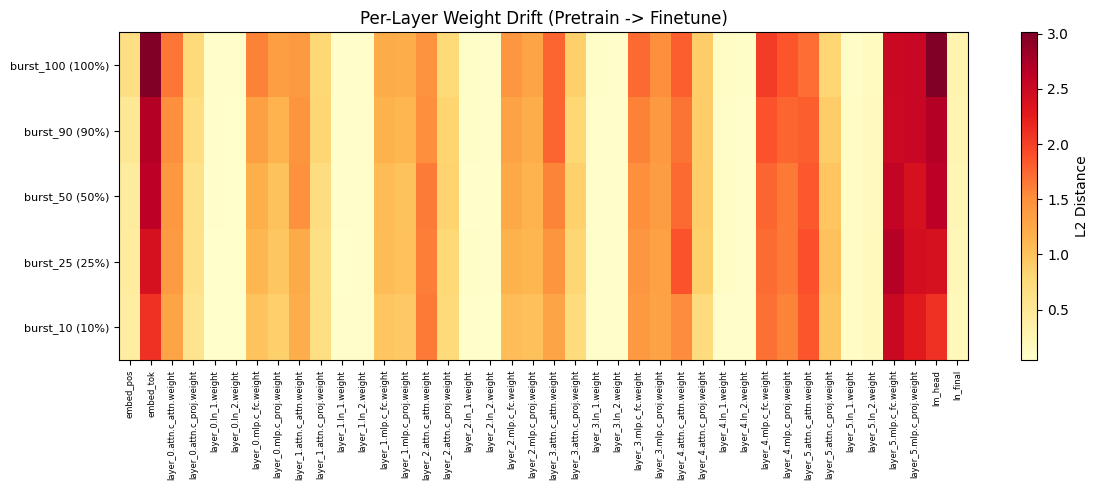

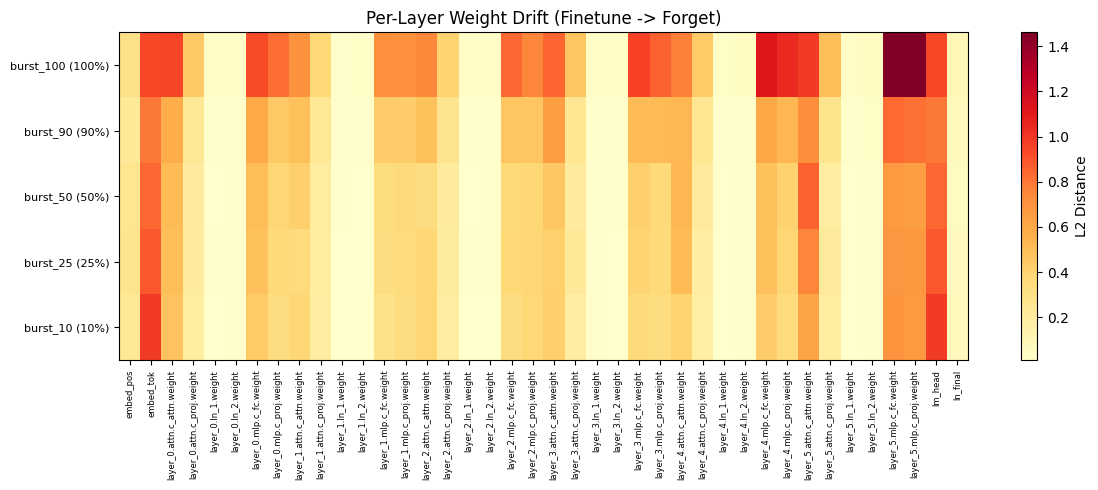

In [27]:
# Per-layer weight drift heatmaps
fig = report.plot_per_layer_drift(analysis, "pt_ft")
plt.show()

fig = report.plot_per_layer_drift(analysis, "ft_fg")
plt.show()

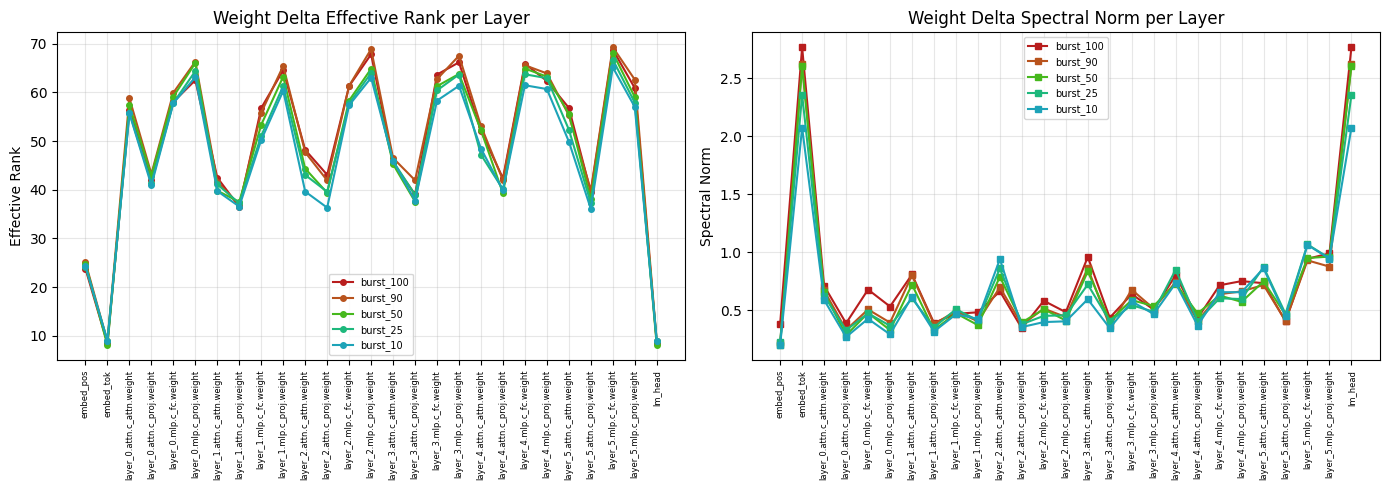

In [28]:
# SVD analysis: effective rank and spectral norm of weight deltas
fig = report.plot_svd_analysis(analysis)
plt.show()

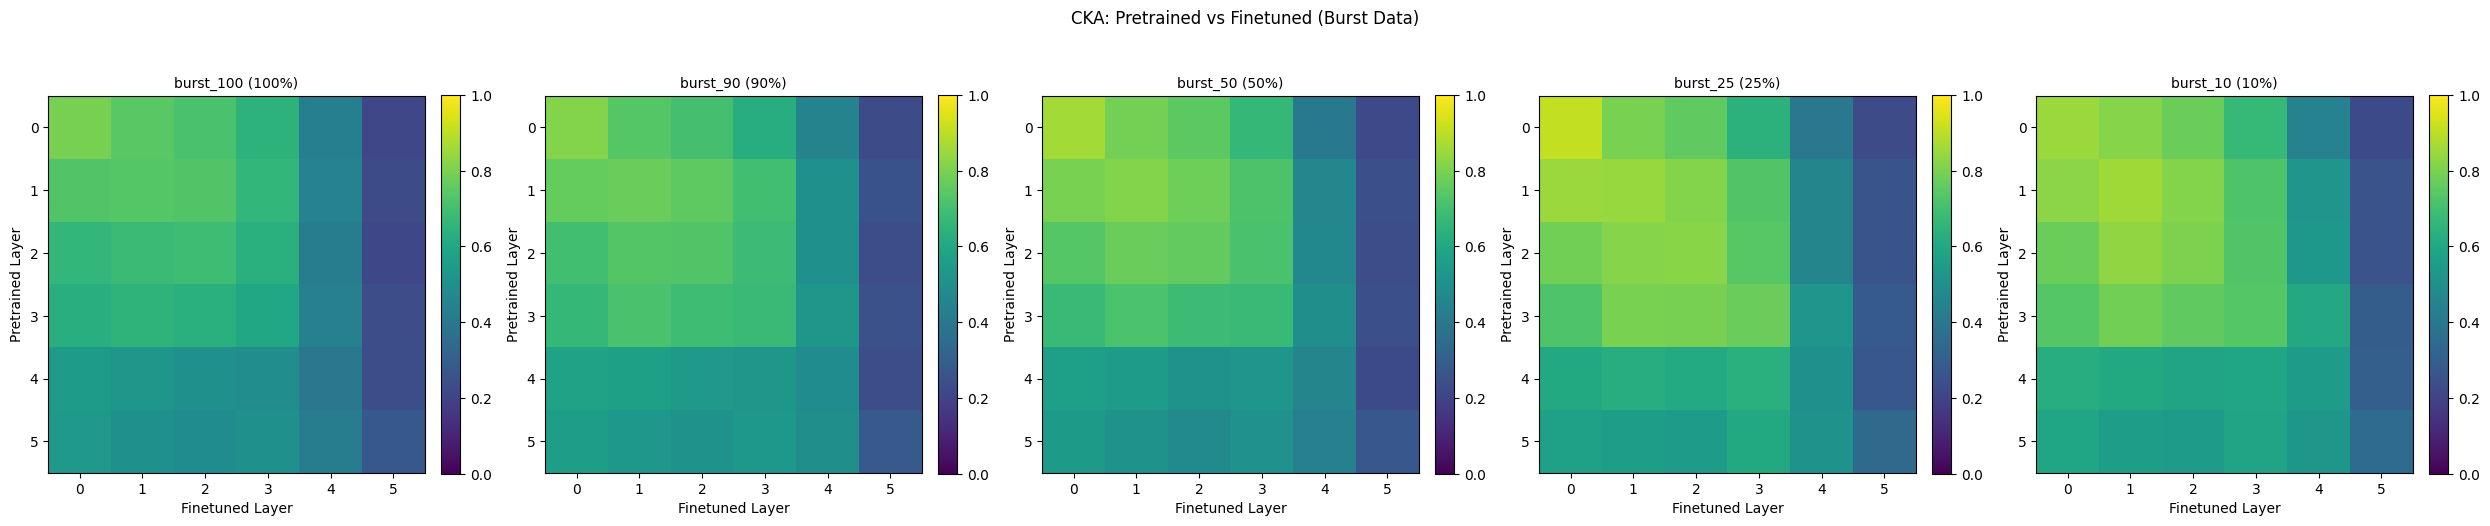

In [29]:
# CKA: representation similarity between pretrained and finetuned models
fig = report.plot_cka_matrices(analysis)
plt.show()

### Representation Movement

How do burst vs background representations separate, move, and collapse across phases?

In [ ]:
import importlib, simple.report
importlib.reload(simple.report)
from simple import report

# Fisher separation per layer: how separable are burst vs bg at each phase?
fig = report.plot_separation_profile(rep_analysis)
plt.show()

AttributeError: module 'simple.report' has no attribute 'plot_separation_profile'

In [ ]:
# Linear probing: can a linear classifier tell burst from bg at each layer?
fig = report.plot_probing_profile(rep_analysis)
plt.show()

In [ ]:
# Centroid drift: how far do burst vs bg representations move from pretrained?
fig = report.plot_representation_drift(rep_analysis)
plt.show()

In [ ]:
# PCA: where do burst and bg clusters sit across models?
fig = report.plot_pca_scatter(rep_analysis, "_pca_last_layer")
plt.show()

fig = report.plot_pca_scatter(rep_analysis, "_pca_mid_layer")
plt.show()

In [ ]:
# Summary: mean separation & probing vs burst fraction across all 3 phases
fig = report.plot_separation_summary(rep_analysis)
plt.show()

In [ ]:
# Loss landscape sharpness
fig, ax = plt.subplots(figsize=(8, 4))
report.plot_sharpness(analysis, ax)
plt.show()

## 7. Summary Dashboard & Full Report

In [ ]:
# Summary dashboard: all key metrics vs burst fraction
fig = report.plot_summary_dashboard(ft_results, fg_results, analysis)
plt.show()

In [ ]:
# Save all charts to disk (training + interp + representation)
report.save_report(pt, ft_results, fg_results, f"{OUT}/report",
                   analysis=analysis, rep_analysis=rep_analysis)